In [144]:
import matplotlib.pyplot as plt
from pathlib import Path
from ase.io import read
import numpy as np

In [147]:
data = [[f.name, read(f, format='espresso-out').get_total_energy()] for f in Path().cwd().glob('scf_*.out')]
data.sort(key= lambda x: x[1], reverse=True)
data

[['scf_kpoint.4.out', -3681.070434021213],
 ['scf_kpoint.5.out', -3681.085689811463],
 ['scf_kpoint.6.out', -3681.0891896035987],
 ['scf_kpoint.7.out', -3681.0901984656557],
 ['scf_kpoint.8.out', -3681.0905475877107],
 ['scf_kpoint.9.out', -3681.090689631134],
 ['scf_kpoint.10.out', -3681.0907554826836],
 ['scf_kpoint.11.out', -3681.0907881363437],
 ['scf_kpoint.12.out', -3681.0908035107764]]

In [151]:
energies = [x[1] for x in data]
energies

[-3681.070434021213,
 -3681.085689811463,
 -3681.0891896035987,
 -3681.0901984656557,
 -3681.0905475877107,
 -3681.090689631134,
 -3681.0907554826836,
 -3681.0907881363437,
 -3681.0908035107764]

In [166]:
deltaE = abs( np.insert(np.diff(energies), 0, 0) )
deltaE

array([0.00000000e+00, 1.52557903e-02, 3.49979214e-03, 1.00886206e-03,
       3.49122055e-04, 1.42043423e-04, 6.58515496e-05, 3.26536601e-05,
       1.53744327e-05])

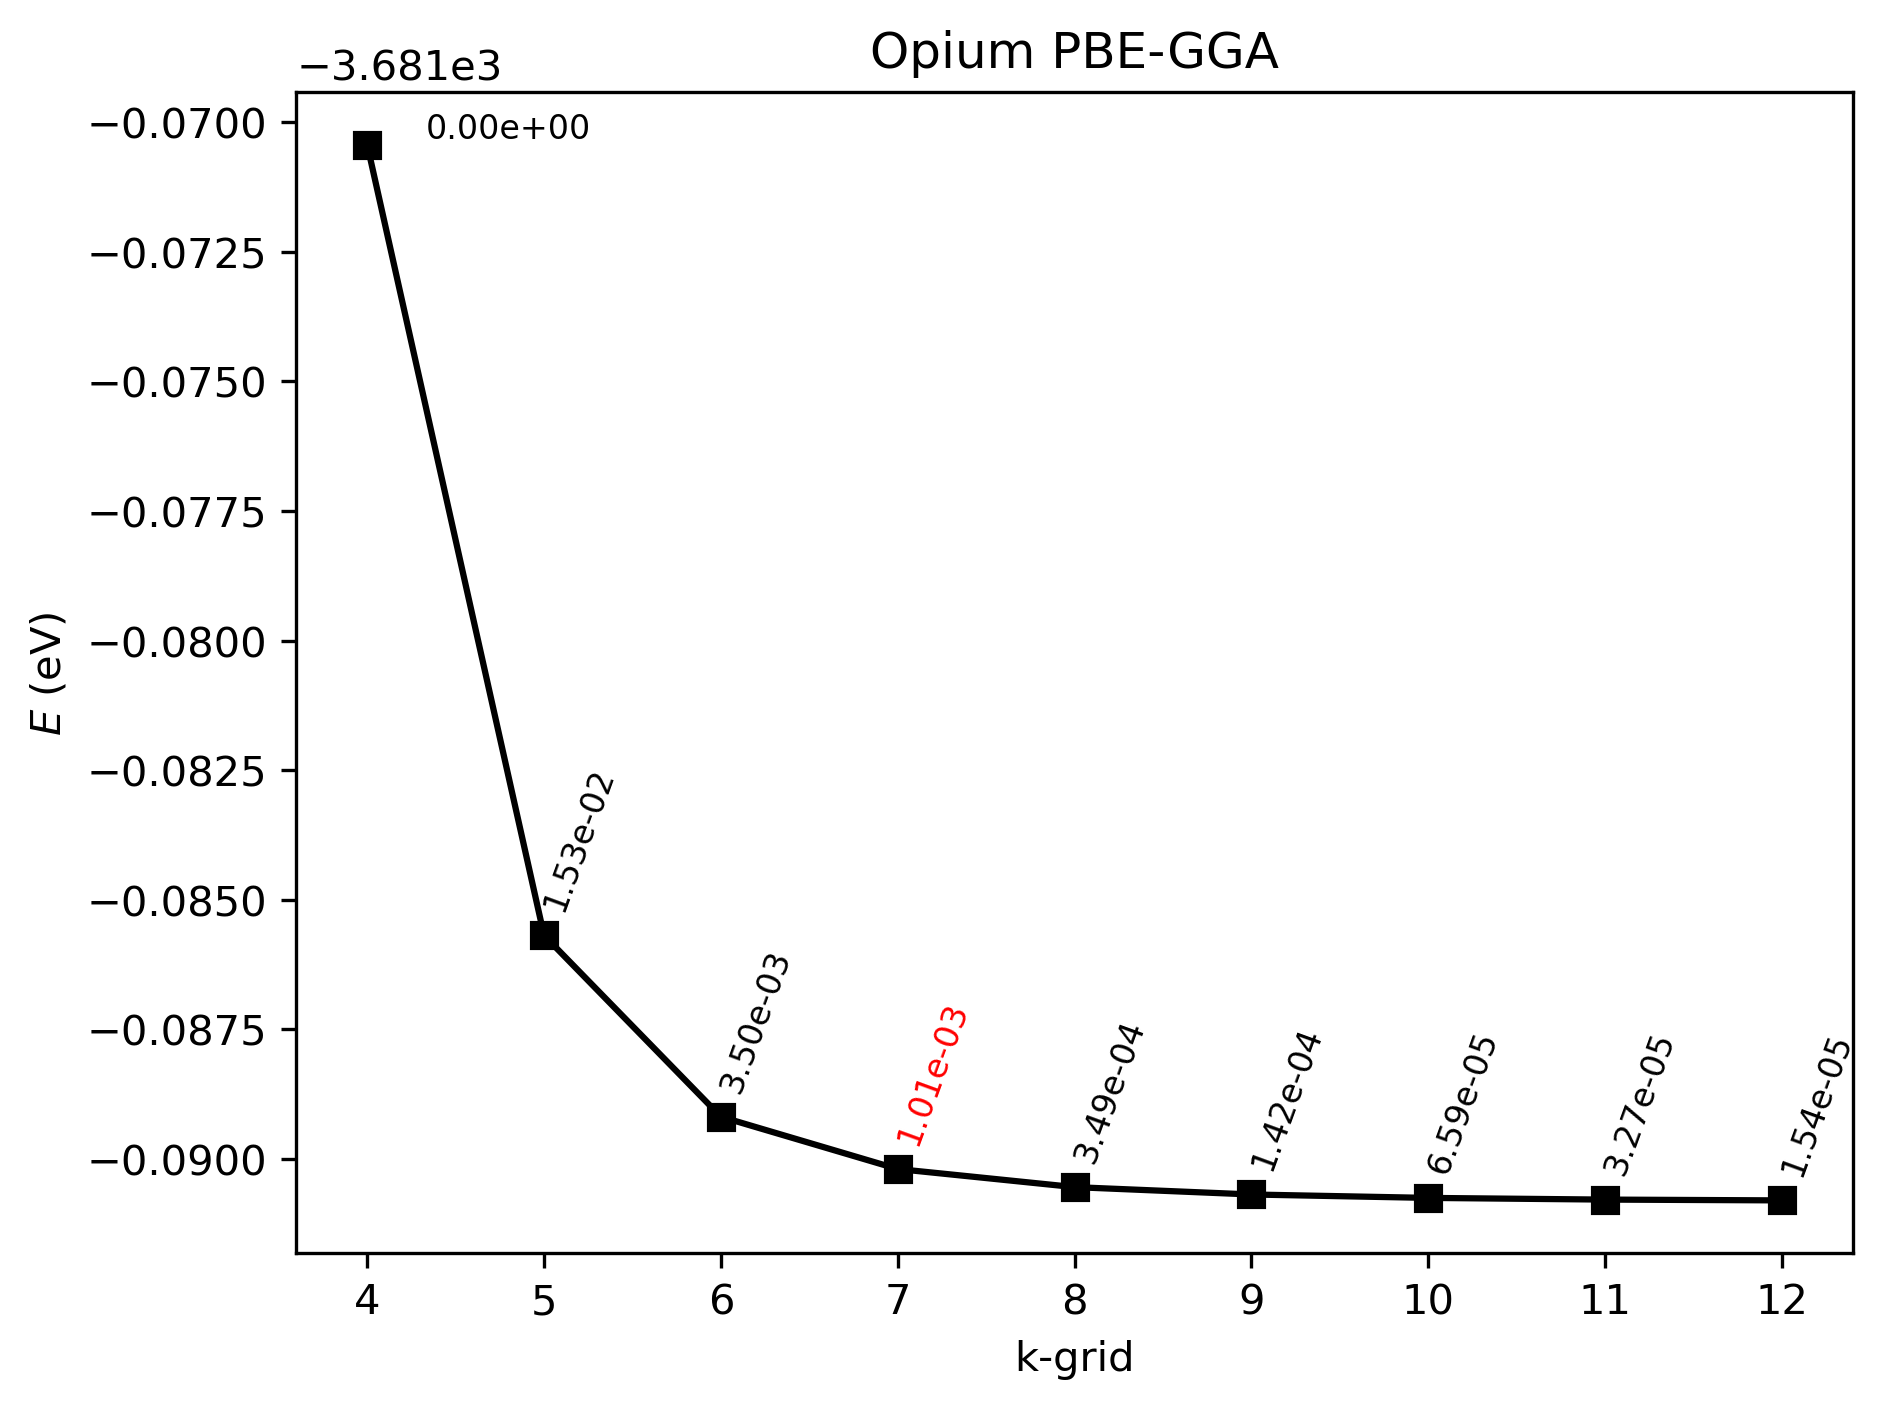

In [178]:
fig  = plt.figure(dpi=300)

plt.title('Opium PBE-GGA')
k = range(4,13,1)
plt.plot(k, energies, marker='s', color='k')
plt.xlabel('k-grid')
plt.ylabel(r'$E$ (eV)')
for i, (x, y) in enumerate(zip(k, energies)):
    if i == 0:
        plt.text(x+.8, y, f'{deltaE[i]:.2e}', fontsize=8, ha='center', va='bottom', rotation=0)
    elif i == 3:
        plt.text(x+0.2, y+4e-4, f'{deltaE[i]:.2e}', fontsize=8, ha='center', va='bottom', rotation=70, color='red')
    else:
        plt.text(x+0.2, y+4e-4, f'{deltaE[i]:.2e}', fontsize=8, ha='center', va='bottom', rotation=70)
plt.tight_layout()
plt.savefig('kpoints.pdf')
plt.show()

ecutwfc = 80 Ry  
k-grid = 7x7x5